# Użycie PySpark w celu eksploracji i wizualizacji danych (Wariant: Jakość Wina)

Zadanie polega na eksploracji i wizualizacji danych dotyczących jakości wina (czerwonego i białego) z użyciem API Spark przez bibliotekę PySpark.

## 1. Konfigurowanie środowiska i sesja Spark
Konfigurujemy ścieżki środowiskowe `JAVA_HOME` oraz `HADOOP_HOME` (wymagane na systemie Windows) i tworzymy lokalną sesję Spark.

In [29]:
import os
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.functions import lit
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.functions import col
from pyspark.sql import functions as f

In [30]:


# Konfiguracja środowiska Java i Hadoop dla systemu Windows
if 'JAVA_HOME' not in os.environ:
    os.environ['JAVA_HOME'] = r'C:\Program Files\KNIME\plugins\org.knime.binary.jre.win32.x86_64_17.0.5.20221116\jre'

os.environ['HADOOP_HOME'] = r'C:\User s\Patryk\antigravity\hadoop'
os.environ['PATH'] = os.path.join(os.environ['HADOOP_HOME'], 'bin') + os.pathsep + os.environ['PATH']



spark = SparkSession.builder \
        .master("local[*]") \
        .appName('PySpark_Lab1_WineQuality') \
        .getOrCreate()

print(spark)

## 2. Pobieranie i czytanie danych
Odczytujemy dane o jakości wina z plików CSV lokalnie.

In [31]:
notebook_dir = os.getcwd()
if os.path.basename(notebook_dir) == 'lab1':
    data_dir = '../data'
    output_dir = 'data'
    plots_dir = 'plots'
else:
    data_dir = 'data'
    output_dir = 'lab1/data'
    plots_dir = 'lab1/plots'

red_csv = os.path.join(data_dir, 'winequality-red.csv')
white_csv = os.path.join(data_dir, 'winequality-white.csv')

# Czytanie plików CSV lokalnie z separatorem ';'
df_red = spark.read.csv(red_csv, sep=';', header=True, inferSchema=True)
df_white = spark.read.csv(white_csv, sep=';', header=True, inferSchema=True)

# Dodanie typu wina
df_red = df_red.withColumn("type", lit("red"))
df_white = df_white.withColumn("type", lit("white"))

# Połączenie zbiorów
df_wine = df_red.union(df_white)
print("Wczytano pliki. Łączna liczba wierszy:", df_wine.count())

Wczytano pliki. Łączna liczba wierszy: 6497


## 3. Strukturyzacja danych za pomocą schematu Spark
Czyścimy nazwy kolumn (usuwamy spacje i cudzysłowy) oraz rzutujemy wybrane kolumny na odpowiednie typy (DoubleType/IntegerType).

In [32]:

# Czyszczenie nazw kolumn
for column_name in df_wine.columns:
    cleaned_name = column_name.replace('"', '').strip().replace(' ', '_')
    df_wine = df_wine.withColumnRenamed(column_name, cleaned_name)

# Rzutowanie typów
double_cols = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
    "pH", "sulphates", "alcohol"
]
for dc in double_cols:
    df_wine = df_wine.withColumn(dc, col(dc).cast(DoubleType()))
data = df_wine.withColumn("quality", col("quality").cast(IntegerType()))

data.printSchema()

root
 |-- fixed_acidity: double (nullable = true)
 |-- volatile_acidity: double (nullable = true)
 |-- citric_acid: double (nullable = true)
 |-- residual_sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free_sulfur_dioxide: double (nullable = true)
 |-- total_sulfur_dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- type: string (nullable = false)



## 4. Metody kontroli danych
Sprawdzamy typy danych, liczbę wierszy, pierwsze rekordy oraz podstawowe statystyki opisowe.

In [33]:
# Typy kolumn
print("Typy kolumn:", data.dtypes)

# Liczba rekordów
print("Całkowita liczba rekordów:", data.count())

# Podgląd pierwszych wierszy
data.show(5)

# Podstawowe statystyki dla wybranych kolumn
data.select(['alcohol', 'pH', 'volatile_acidity', 'quality']).describe().show()

Typy kolumn: [('fixed_acidity', 'double'), ('volatile_acidity', 'double'), ('citric_acid', 'double'), ('residual_sugar', 'double'), ('chlorides', 'double'), ('free_sulfur_dioxide', 'double'), ('total_sulfur_dioxide', 'double'), ('density', 'double'), ('pH', 'double'), ('sulphates', 'double'), ('alcohol', 'double'), ('quality', 'int'), ('type', 'string')]
Całkowita liczba rekordów: 6497
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+----+
|fixed_acidity|volatile_acidity|citric_acid|residual_sugar|chlorides|free_sulfur_dioxide|total_sulfur_dioxide|density|  pH|sulphates|alcohol|quality|type|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+----+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|     

## 5. Radzenie sobie z brakującymi wartościami
Sprawdzamy, czy w kluczowych kolumnach występują braki danych (NULL) i ewentualnie je oczyszczamy.

In [34]:
# Sprawdzenie wierszy z brakującymi danymi
missing_count = data.filter(
    col("quality").isNull() | col("alcohol").isNull() | col("pH").isNull()
).count()
print(f"Liczba wierszy z brakami: {missing_count}")

# Oczyszczanie danych
cleaned_data = data.na.drop(subset=["quality", "alcohol", "pH"])
print("Liczba wierszy po oczyszczeniu danych:", cleaned_data.count())

Liczba wierszy z brakami: 0
Liczba wierszy po oczyszczeniu danych: 6497


## 6. Zapytania, filtrowanie i agregacje danych
Filtrujemy dane o wysokiej jakości oraz wyliczamy agregacje (średnie zawartości alkoholu, kwasowości, pH i cukru dla każdego poziomu jakości).

In [35]:
# 6.1. Wybór kolumn (Select)
cleaned_data.select('type', 'alcohol', 'quality').show(5)

# 6.2. Filtrowanie (Filter) - wina o jakości wyższej niż 6
filtered_data = cleaned_data.filter(col('quality') > 6)
print("Liczba wierszy po przefiltrowaniu (wysoka jakość):", filtered_data.count())

# 6.3. GroupBy i Agregacja (grupowanie po typie i jakości)
wine_stats = cleaned_data.groupBy("type", "quality") \
    .agg(
        f.avg("alcohol").alias("avg_alcohol"),
        f.avg("volatile_acidity").alias("avg_volatile_acidity"),
        f.avg("pH").alias("avg_pH"),
        f.avg("residual_sugar").alias("avg_residual_sugar"),
        f.count("quality").alias("count")
    ) \
    .orderBy("type", "quality")

wine_stats.show(20)

+----+-------+-------+
|type|alcohol|quality|
+----+-------+-------+
| red|    9.4|      5|
| red|    9.8|      5|
| red|    9.8|      5|
| red|    9.8|      6|
| red|    9.4|      5|
+----+-------+-------+
only showing top 5 rows
Liczba wierszy po przefiltrowaniu (wysoka jakość): 1277
+-----+-------+------------------+--------------------+------------------+------------------+-----+
| type|quality|       avg_alcohol|avg_volatile_acidity|            avg_pH|avg_residual_sugar|count|
+-----+-------+------------------+--------------------+------------------+------------------+-----+
|  red|      3| 9.955000000000002|  0.8845000000000001|3.3979999999999997|2.6350000000000002|   10|
|  red|      4|10.265094339622639|  0.6939622641509429| 3.381509433962264|  2.69433962264151|   53|
|  red|      5| 9.899706314243753|  0.5770411160058732|3.3049486049926546| 2.528854625550658|  681|
|  red|      6|10.629519331243463| 0.49748432601880965|3.3180721003134837| 2.477194357366772|  638|
|  red|      

## 7. Wizualizacja danych
Konwertujemy wyniki Spark DataFrame do Pandas DataFrame w celu wygenerowania wykresów za pomocą biblioteki `matplotlib` i `seaborn`. Wykresy zostaną zapisane w katalogu `plots`.

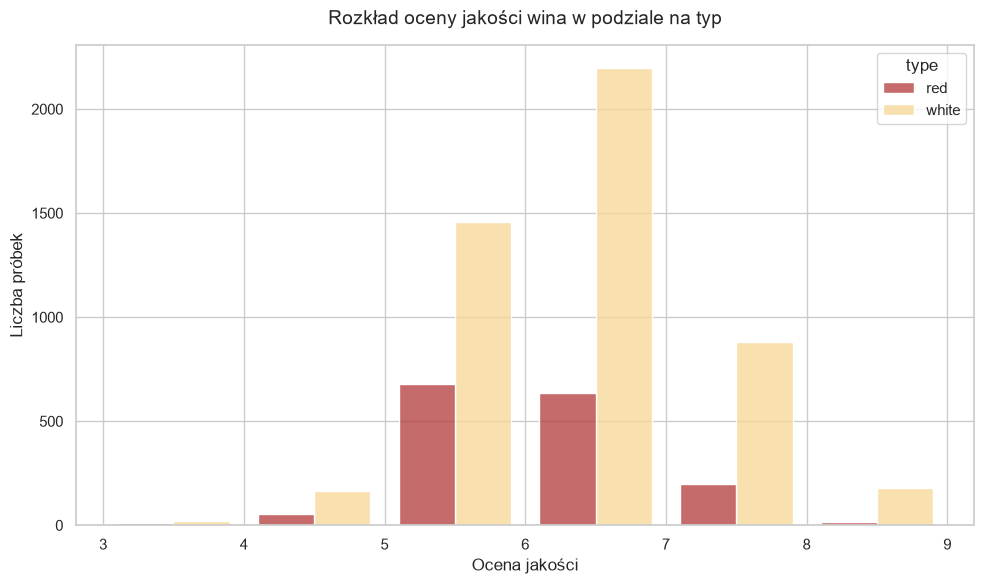

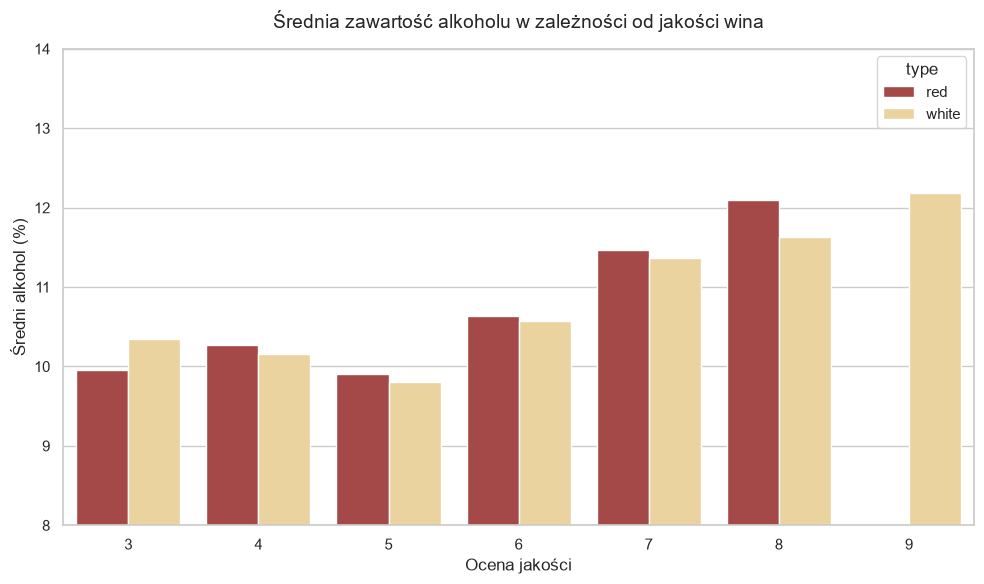

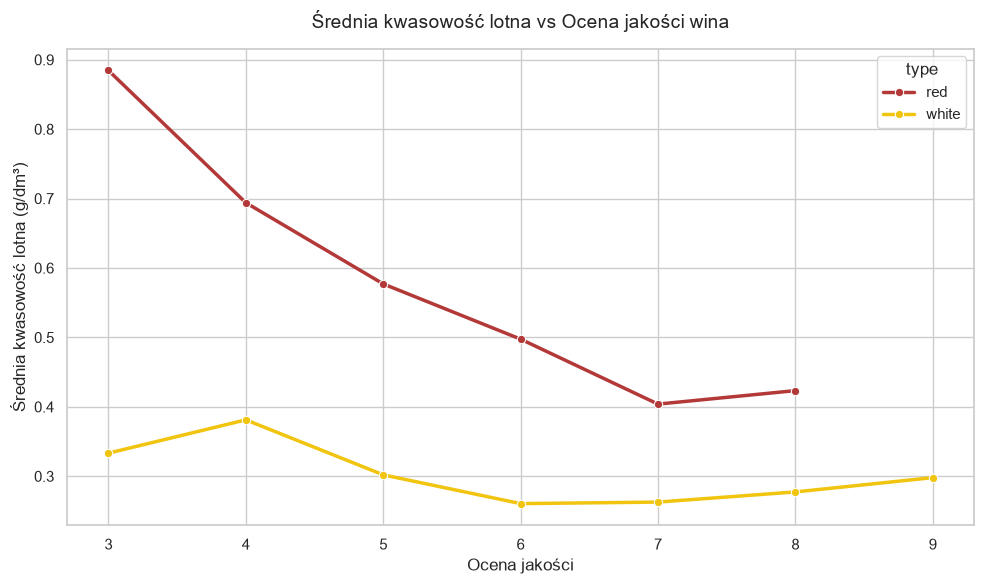

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd_stats = wine_stats.toPandas()
pd_full = cleaned_data.select("type", "quality", "alcohol", "volatile_acidity").toPandas()

# Wykres 1: Rozkład oceny jakości wina w podziale na typ
fig, ax = plt.subplots(figsize=(10, 6))
_histplot = sns.histplot(
    data=pd_full, 
    x="quality", 
    hue="type", 
    multiple="dodge", 
    shrink=0.8, 
    bins=[3, 4, 5, 6, 7, 8, 9], 
    palette={"red": "#b33939", "white": "#f7d794"},
    ax=ax
)
plt.title("Rozkład oceny jakości wina w podziale na typ", fontsize=14, pad=15)
plt.xlabel("Ocena jakości", fontsize=12)
plt.ylabel("Liczba próbek", fontsize=12)
plt.xticks([3, 4, 5, 6, 7, 8, 9])
plt.tight_layout()
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'quality_distribution.png'), dpi=150)
plt.show()

# Wykres 2: Średnia zawartość alkoholu w zależności od jakości
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=pd_stats, 
    x="quality", 
    y="avg_alcohol", 
    hue="type", 
    palette={"red": "#b33939", "white": "#f7d794"},
    ax=ax
)
plt.title("Średnia zawartość alkoholu w zależności od jakości wina", fontsize=14, pad=15)
plt.xlabel("Ocena jakości", fontsize=12)
plt.ylabel("Średni alkohol (%)", fontsize=12)
plt.ylim(8, 14)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'alcohol_vs_quality.png'), dpi=150)
plt.show()

# Wykres 3: Średnia kwasowość lotna w zależności od jakości wina
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=pd_stats, 
    x="quality", 
    y="avg_volatile_acidity", 
    hue="type", 
    marker="o", 
    linewidth=2.5, 
    palette={"red": "#b33939", "white": "#f1c40f"},
    ax=ax
)
plt.title("Średnia kwasowość lotna vs Ocena jakości wina", fontsize=14, pad=15)
plt.xlabel("Ocena jakości", fontsize=12)
plt.ylabel("Średnia kwasowość lotna (g/dm³)", fontsize=12)
plt.xticks([3, 4, 5, 6, 7, 8, 9])
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'volatile_acidity_vs_quality.png'), dpi=150)
plt.show()

## 8. Zapisywanie danych do pliku
Zapisujemy zagregowane statystyki do formatów CSV, JSON i Parquet, a następnie zamykamy sesję Spark.

In [37]:
csv_out = os.path.join(output_dir, 'wine_quality_stats.csv')
json_out = os.path.join(output_dir, 'wine_quality_stats.json')
parquet_out = os.path.join(output_dir, 'wine_quality_stats.parquet')

for p in [csv_out, json_out, parquet_out]:
    if os.path.exists(p):
        shutil.rmtree(p, ignore_errors=True)

wine_stats.write.csv(csv_out, header=True)
print("Zapisano dane do:", csv_out)

wine_stats.write.save(json_out, format='json')
print("Zapisano dane do:", json_out)

wine_stats.write.save(parquet_out, format='parquet')
print("Zapisano dane do:", parquet_out)

spark.stop()
print("Sesja Spark została pomyślnie zamknięta.")

Zapisano dane do: data\wine_quality_stats.csv
Zapisano dane do: data\wine_quality_stats.json
Zapisano dane do: data\wine_quality_stats.parquet
Sesja Spark została pomyślnie zamknięta.
